In [1]:
import datasets
from datasets import ClassLabel
import numpy as np
import torch
from transformers import AutoTokenizer
from tqdm import tqdm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, accuracy_score, f1_score
import plotly.io as pio
import plotly.graph_objects as go
import kaleido

#from kaleido.scopes.plotly import PlotlyScope

#scope = PlotlyScope()
#pio.kaleido.scope.chromium_args = tuple(
#    [arg for arg in scope.chromium_args if arg != "--disable-dev-shm-usage"])

# ignore futurewarning
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

# GCDC na GCDC (Vanilla vs POSMix vs RSTMix)

In [2]:
ds_vanilla = datasets.load_from_disk(
    'results/gcdc_Vanilla_1_Cycles_0.0_WarmR_in_gcdc_scores')['validation']
ds_rst = datasets.load_from_disk(
    'results/gcdc_RSTMix_1_Cycles_0.0_WarmR_in_gcdc_scores')['validation']
ds_pos = datasets.load_from_disk(
    'results/gcdc_POSMix_LoKr_1_Cycles_0.0_WarmR_1e-05_lr_in_gcdc_scores'
)['validation']

In [3]:
def gcdc_label(dataset):
  dataset = dataset.filter(lambda e: e["label"] != 1)
  # tranform labels to [0, 1]
  dataset = dataset.map(
      lambda e: {"label": 0 if e["label"] == 0 else 1},
      remove_columns=["label"],
      desc="Transforming labels to [0, 1]",
  )
  dataset = dataset.cast_column("label", ClassLabel(names=["0", "1"]))
  return dataset

In [4]:
ds_vanilla = gcdc_label(ds_vanilla)
ds_rst = gcdc_label(ds_rst)
ds_pos = gcdc_label(ds_pos)

In [5]:
columns_vanilla = [c for c in ds_vanilla.column_names if "gcdc" in c]
oolumns_rst = [c for c in ds_rst.column_names if "gcdc" in c]
columns_pos = [c for c in ds_pos.column_names if "gcdc" in c]

In [6]:
def preds_with_probs(ds, columns):
  preds = {
      'run': [],
      'correct_ids': [],
      'correct_logits': [],
      'correct_lenght': [],
      'wrong_ids': [],
      'wrong_logits': [],
      'wrong_lenght': [],
      'source_name': [],
      'label': []
  }
  for k in columns:
    for row_idx in tqdm(range(ds.num_rows)):
      predicted = np.argmax(ds[row_idx][k][0])
      label = ds[row_idx]['label']
      preds['run'].append(k)
      preds['source_name'].append(ds[row_idx]['source_name'])
      preds['label'].append(label)
      if predicted == label:
        preds['correct_ids'].append(row_idx)
        preds['correct_logits'].append(ds[row_idx][k][0][predicted])
        preds['correct_lenght'].append(int(ds[row_idx][k][1][0]))
      else:
        preds['wrong_ids'].append(row_idx)
        preds['wrong_logits'].append(ds[row_idx][k][0][predicted])
        preds['wrong_lenght'].append(int(ds[row_idx][k][1][0]))
  return preds


preds_vanilla = preds_with_probs(ds_vanilla, columns_vanilla)
preds_rst = preds_with_probs(ds_rst, oolumns_rst)
preds_pos = preds_with_probs(ds_pos, columns_pos)

100%|████████████████████████████████████████| 641/641 [00:05<00:00, 124.46it/s]


In [7]:
symbols = {
    'Vanilla': 'circle',
    'RSTMix': 'square',
    'POSMix': 'diamond',
}
# make each preds group as a trace in subplot
temp_pred = {
    'logits': [],
    'length': [],
    'Prediction': [],
    'Pipeline': [],
    'Source': [],
    'Label': [],
}
for idx, preds in enumerate([preds_vanilla, preds_rst, preds_pos]):
  if 'Vanilla' in preds['run'][0]:
    Pipeline = 'Vanilla'
  elif 'RSTMix' in preds['run'][0]:
    Pipeline = 'RSTMix'
  else:
    Pipeline = 'POSMix'
  temp_pred['logits'].extend(preds['correct_logits'])
  temp_pred['logits'].extend(preds['wrong_logits'])
  temp_pred['length'].extend(preds['correct_lenght'])
  temp_pred['length'].extend(preds['wrong_lenght'])
  temp_pred['Prediction'].extend(['Correct'] * len(preds['correct_logits']))
  temp_pred['Prediction'].extend(['Wrong'] * len(preds['wrong_logits']))
  temp_pred['Pipeline'].extend(
      [Pipeline] * (len(preds['correct_logits']) + len(preds['wrong_logits'])))
  temp_pred['Source'].extend(preds['source_name'])
  temp_pred['Label'].extend(preds['label'])

In [8]:
temp_df = pd.DataFrame(temp_pred)
temp_df

,logits,length,Prediction,Pipeline,Source,Label
0,0.966023,223,Correct,Vanilla,Clinton,1
1,0.854739,246,Correct,Vanilla,Clinton,0
2,0.957784,183,Correct,Vanilla,Clinton,1
3,0.789953,298,Correct,Vanilla,Clinton,0
4,0.968302,186,Correct,Vanilla,Clinton,1
...,...,...,...,...,...,...
9610,0.530640,123,Wrong,POSMix,Yahoo,0
9611,0.526241,140,Wrong,POSMix,Yahoo,0
9612,0.527812,144,Wrong,POSMix,Yahoo,0
9613,0.529268,165,Wrong,POSMix,Yahoo,1


In [9]:
from os import name

fig2 = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=['Vanilla', 'RSTMix', 'POSMix'],
    horizontal_spacing=0.05,
    shared_yaxes=True,
)

show_legend = True
for idx, source in enumerate(['Clinton', 'Yelp', 'Enron', 'Yahoo']):
  for jdx, pipeline in enumerate(['Vanilla', 'RSTMix', 'POSMix']):
    sources_df = temp_df[temp_df['Pipeline'] == pipeline]
    correct = sources_df[sources_df['Prediction'] == 'Correct']
    wrong = sources_df[sources_df['Prediction'] == 'Wrong']
    fig2.add_trace(
        go.Violin(
            y=wrong[wrong['Source'] == source]['logits'],
            x=wrong[wrong['Source'] == source]['Source'],
            name='Predição Errada',
            side='negative',
            fillcolor='red',
            line_color='red',
            width=0.5,
            showlegend=show_legend,
            opacity=0.7,
        ),
        row=1,
        col=jdx + 1,
    )
    fig2.add_trace(
        go.Violin(
            y=correct[correct['Source'] == source]['logits'],
            x=correct[correct['Source'] == source]['Source'],
            name='Predição Correta',
            side='positive',
            fillcolor='green',
            line_color='green',
            width=0.5,
            opacity=0.7,
            showlegend=show_legend,
        ),
        row=1,
        col=jdx + 1,
    )
    show_legend = False
fig2.update_traces(
    meanline_visible=True,
    meanline_width=10,
    meanline_color='black',
    spanmode='hard',
)

fig2.update_layout(
    xaxis_title='Subconjuntos',
    xaxis2_title='Subconjuntos',
    xaxis3_title='Subconjuntos',
    yaxis_title='Probabilidade',
    yaxis1=dict(nticks=10),
    yaxis2=dict(nticks=10),
    yaxis3=dict(nticks=10),
    font_size=20,
)
fig2.update_annotations(font_size=20)
fig2.update_layout(height=600, width=1400, plot_bgcolor="white")
fig2.update_xaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey')
fig2.update_yaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey')
fig2.write_image("figs/gcdc_prob_by_source.svg")
fig2.show()

In [23]:
yelp = {
    'Vanilla': (0.6452069716775599, 0.5958605664488017, 0.7140522875816994),
    'POSMix': (0.5907407407407407, 0.5620915032679739, 0.6045751633986929),
    'RSTMix': (0.5974945533769063, 0.5599128540305011, 0.6443355119825708),
}
yahoo = {
    'Vanilla': (0.7411939411939412, 0.7216364716364716, 0.7650727650727651),
    'POSMix': (0.7265963765963767, 0.6738936738936738, 0.7562370062370063),
    'RSTMix': (0.7051232551232551, 0.6211761211761212, 0.7561627561627562),
}
enron = {
    'Vanilla': (0.7238943894389439, 0.7018151815181518, 0.7518151815181517),
    'POSMix': (0.7043564356435643, 0.6919141914191419, 0.7286303630363036),
    'RSTMix': (0.705874587458746, 0.6734323432343234, 0.7439768976897689),
}

Clinton = {
    'Vanilla': (0.731217750257998, 0.6898864809081527, 0.7541279669762642),
    'POSMix': (0.6770381836945305, 0.6470588235294118, 0.6937564499484004),
    'RSTMix': (0.646594427244582, 0.5652734778121775, 0.7079463364293086),
}

In [24]:
import plotly.express as px

In [46]:
round_df = temp_df.copy()
round_df['logits'] = round_df['logits'].round(1)
# round length by 10
round_df['length'] = round_df['length'] // 10 * 10
round_df1 = round_df[round_df["Prediction"] == "Correct"]
round_df2 = round_df[round_df["Prediction"] == "Wrong"]
#round_df1 = round_df1.sort_values(by='length')
round_df1.reset_index(inplace=True, drop=True)
round_df1 = round_df1.groupby(['Pipeline', 'logits',
                               'length']).size().reset_index(name='count')
round_df1["count"] = round_df1["count"].apply(
    lambda x: x / round_df1["count"].sum())
round_df1

,Pipeline,logits,length,count
0,POSMix,0.5,110,0.000318
1,POSMix,0.5,120,0.003496
2,POSMix,0.5,130,0.010806
3,POSMix,0.5,140,0.010170
4,POSMix,0.5,150,0.011759
...,...,...,...,...
378,Vanilla,1.0,360,0.005085
379,Vanilla,1.0,370,0.001589
380,Vanilla,1.0,380,0.001430
381,Vanilla,1.0,400,0.000477


In [47]:
round_df2 = round_df2.sort_values(by='length')
round_df2.reset_index(inplace=True, drop=True)
round_df2 = round_df2.groupby(['Pipeline', 'logits',
                               'length']).size().reset_index(name='count')
round_df2["count"] = round_df2["count"].apply(
    lambda x: x / round_df2["count"].sum())
round_df2

,Pipeline,logits,length,count
0,POSMix,0.5,110,0.000602
1,POSMix,0.5,120,0.003612
2,POSMix,0.5,130,0.010837
3,POSMix,0.5,140,0.016255
4,POSMix,0.5,150,0.018061
...,...,...,...,...
351,Vanilla,1.0,330,0.000602
352,Vanilla,1.0,370,0.001204
353,Vanilla,1.0,380,0.001505
354,Vanilla,1.0,390,0.001505


In [48]:
fig3 = px.scatter(round_df1,
                  x="length",
                  y="logits",
                  size="count",
                  color="Pipeline",
                  size_max=60)
fig3.update_annotations(font_size=20)
fig3.update_layout(height=600, width=1400, plot_bgcolor="white")
fig3.update_xaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey',
                  tickvals=[100, 150, 200, 250, 300, 350, 400])
fig3.update_yaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey')
fig3.update_layout(
    xaxis_title="Text length",
    yaxis_title="Probabilty of correct predictions",
    font_size=20,
    legend=dict(
        itemsizing='constant',  # Garante tamanho uniforme para os marcadores da legenda
    )
)
fig3.update_annotations(font_size=20)
fig3.write_image("figs/gcdc_prob_dist_correct_pred_length.svg")
fig3.show()

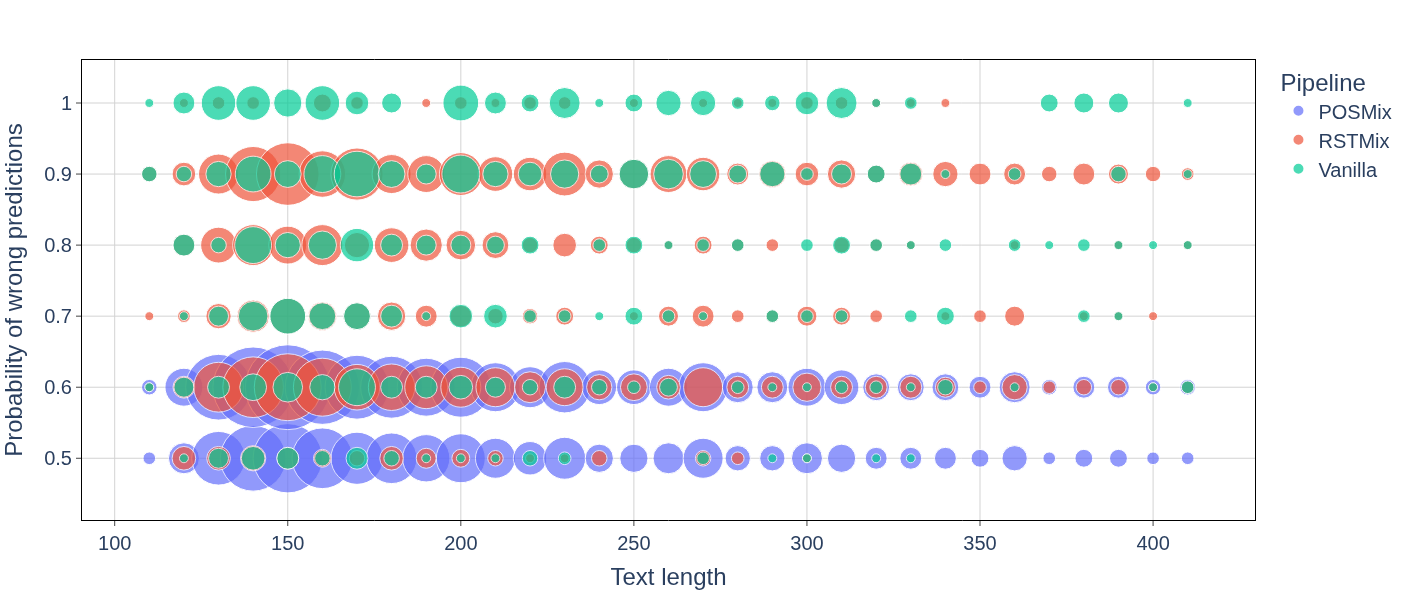

In [49]:
fig4 = px.scatter(round_df2,
                  x="length",
                  y="logits",
                  size="count",
                  color="Pipeline",
                  size_max=60)
fig4.update_annotations(font_size=5)
fig4.update_layout(height=600, width=1400, plot_bgcolor="white")
fig4.update_xaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey')
fig4.update_yaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey')
fig4.update_layout(
    xaxis_title="Text length",
    yaxis_title="Probability of wrong predictions",
    font_size=20,
)
fig4.update_annotations(font_size=5)
fig4.write_image("figs/gcdc_prob_dist_wrong_pred_length.svg")
fig4.show()

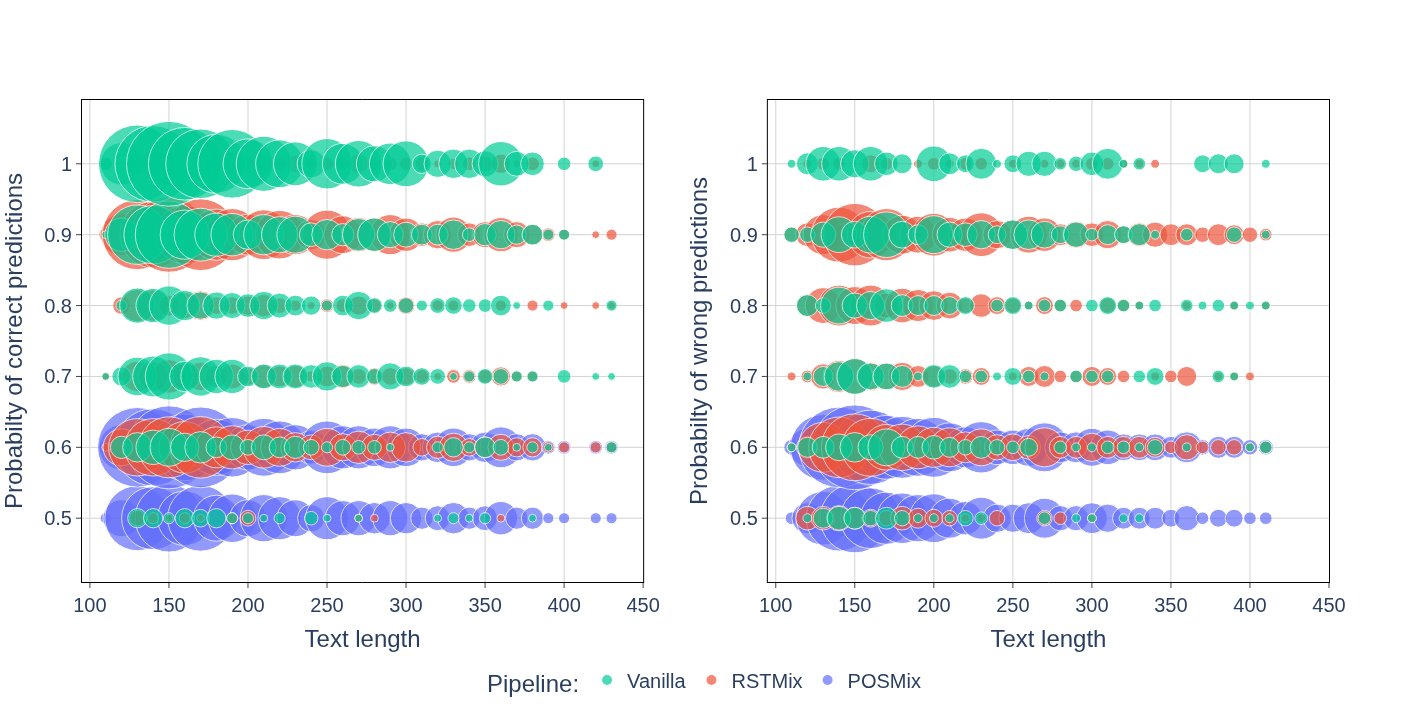

In [67]:
fig = make_subplots(rows=1, cols=2)

for trace in fig3.select_traces():
    fig.add_trace(trace, row=1, col=1)

for trace in fig4.select_traces():
    trace['showlegend'] = False
    fig.add_trace(trace, row=1, col=2)

fig.update_yaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey',
                  title_text="Probabilty of correct predictions",
                  range=[0.41, 1.09],
                  row=1, col=1,)
fig.update_xaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey',
                  title_text="Text length",
                  range=[95, 450],
                  row=1, col=1)

fig.update_yaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey',
                  title_text="Probabilty of wrong predictions",
                  range=[0.41, 1.09],
                  row=1, col=2,)
fig.update_xaxes(mirror=True,
                  ticks='outside',
                  showline=True,
                  linecolor='black',
                  gridcolor='lightgrey',
                  title_text="Text length",
                  range=[95, 450],
                  row=1, col=2)

fig.update_layout(height=700,
                  width=1600,
                  plot_bgcolor="white",
                  font_size=20,
                  showlegend=True,
                  legend=dict(
                      itemsizing='constant',
                      title_text='Pipeline:',
                      traceorder='reversed',
                      orientation="h",   
                      yanchor="bottom",  
                      y=-0.25,            
                      xanchor="center",  
                      x=0.5,
                      font=dict(
                          size=20  # Aumente a fonte da legenda (ex: 18)
                    )
                 )
            )

fig.update_annotations(font_size=20)

fig.write_image("figs/gcdc_prob_dist_both.svg")

fig.show()

In [17]:
source_df = temp_df.copy()
source_df['logits'] = source_df['logits'].round(1)
# source length by 10
source_df['length'] = source_df['length'] // 10 * 10
source_df1 = source_df[source_df["Prediction"] == "Correct"]
source_df2 = source_df[source_df["Prediction"] == "Wrong"]
source_df1 = source_df1.sort_values(by='length')
source_df1.reset_index(inplace=True, drop=True)
source_df1 = source_df1.groupby(['Pipeline', 'Source', 'logits',
                                 'length']).size().reset_index(name='count')
source_df1["count"] = source_df1["count"].apply(
    lambda x: x / source_df1["count"].sum())

In [18]:
pred_df = temp_df.copy()

In [19]:
temp_df

,logits,length,Prediction,Pipeline,Source,Label
0,0.966023,223,Correct,Vanilla,Clinton,1
1,0.854739,246,Correct,Vanilla,Clinton,0
2,0.957784,183,Correct,Vanilla,Clinton,1
3,0.789953,298,Correct,Vanilla,Clinton,0
4,0.968302,186,Correct,Vanilla,Clinton,1
...,...,...,...,...,...,...
9610,0.530640,123,Wrong,POSMix,Yahoo,0
9611,0.526241,140,Wrong,POSMix,Yahoo,0
9612,0.527812,144,Wrong,POSMix,Yahoo,0
9613,0.529268,165,Wrong,POSMix,Yahoo,1


In [20]:
pred_df['Prediction'] = temp_df.apply(
    lambda x: x['Label']
    if x['Prediction'] == 'Correct' else int(not x['Label']),
    axis=1)
pred_df

,logits,length,Prediction,Pipeline,Source,Label
0,0.966023,223,1,Vanilla,Clinton,1
1,0.854739,246,0,Vanilla,Clinton,0
2,0.957784,183,1,Vanilla,Clinton,1
3,0.789953,298,0,Vanilla,Clinton,0
4,0.968302,186,1,Vanilla,Clinton,1
...,...,...,...,...,...,...
9610,0.530640,123,1,POSMix,Yahoo,0
9611,0.526241,140,1,POSMix,Yahoo,0
9612,0.527812,144,1,POSMix,Yahoo,0
9613,0.529268,165,0,POSMix,Yahoo,1


In [21]:
pred_vanilla_df = pred_df[pred_df['Pipeline'] == 'Vanilla']
pred_rst_df = pred_df[pred_df['Pipeline'] == 'RSTMix']
pred_pos_df = pred_df[pred_df['Pipeline'] == 'POSMix']

In [22]:
print(len(pred_vanilla_df), len(pred_rst_df), len(pred_pos_df))

3205 3205 3205


In [23]:
x = pred_vanilla_df[pred_vanilla_df['Prediction'] == pred_vanilla_df['Label']]
x[x['length'] > 250]

,logits,length,Prediction,Pipeline,Source,Label
3,0.789953,298,0,Vanilla,Clinton,0
6,0.958747,386,1,Vanilla,Clinton,1
7,0.980018,369,1,Vanilla,Clinton,1
14,0.916077,330,1,Vanilla,Clinton,1
18,0.938144,339,0,Vanilla,Clinton,0
...,...,...,...,...,...,...
2411,0.654549,259,1,Vanilla,Yahoo,1
2428,0.877776,286,1,Vanilla,Yahoo,1
2429,0.871363,260,1,Vanilla,Yahoo,1
2440,0.919827,277,1,Vanilla,Yahoo,1


In [24]:
x = pred_rst_df[pred_rst_df['Prediction'] == pred_rst_df['Label']]
x = x[x['length'] > 250]
len(x[x['logits'] > 0.8]) / len(x)

0.5863970588235294

In [25]:
x = pred_pos_df[pred_pos_df['Prediction'] == pred_pos_df['Label']]
x[x['length'] > 250]

,logits,length,Prediction,Pipeline,Source,Label
6413,0.539664,386,0,POSMix,Clinton,0
6414,0.543387,369,1,POSMix,Clinton,1
6420,0.542856,330,1,POSMix,Clinton,1
6423,0.541295,339,1,POSMix,Clinton,1
6426,0.543486,360,0,POSMix,Clinton,0
...,...,...,...,...,...,...
8288,0.528119,259,0,POSMix,Yahoo,0
8291,0.527084,304,0,POSMix,Yahoo,0
8293,0.528699,286,0,POSMix,Yahoo,0
8294,0.528150,260,1,POSMix,Yahoo,1


In [26]:
brie_score = {
    "vanilla": {
        "Clinton": 0,
        "Yelp": 0,
        "Enron": 0,
        "Yahoo": 0,
        "all": 0,
    },
    "rstmix": {
        "Clinton": 0,
        "Yelp": 0,
        "Enron": 0,
        "Yahoo": 0,
        "all": 0,
    },
    "posmix": {
        "Clinton": 0,
        "Yelp": 0,
        "Enron": 0,
        "Yahoo": 0,
        "all": 0,
    },
}

In [27]:
from sklearn.metrics import brier_score_loss

brie_loss_vanilla = brier_score_loss(y_true=pred_vanilla_df['Label'],
                                     y_prob=pred_vanilla_df['logits'])
brie_loss_rst = brier_score_loss(y_true=pred_rst_df['Label'],
                                 y_prob=pred_rst_df['logits'])
brie_loss_pos = brier_score_loss(y_true=pred_pos_df['Label'],
                                 y_prob=pred_pos_df['logits'])

brie_score["vanilla"]["all"] = brie_loss_vanilla
brie_score["rstmix"]["all"] = brie_loss_rst
brie_score["posmix"]["all"] = brie_loss_pos

list_sources_vanilla = []
list_sources_rst = []
list_sources_pos = []
for s in ['Clinton', 'Yelp', 'Enron', 'Yahoo']:
  list_sources_vanilla.append(pred_vanilla_df[pred_vanilla_df['Source'] == s])
  list_sources_rst.append(pred_rst_df[pred_rst_df['Source'] == s])
  list_sources_pos.append(pred_pos_df[pred_pos_df['Source'] == s])

brier_loss_sources_vanilla = []
for s in list_sources_vanilla:
  brier_loss_sources_vanilla.append(
      brier_score_loss(y_true=s['Label'], y_prob=s['logits']))
brie_score["vanilla"]["Clinton"] = brier_loss_sources_vanilla[0]
brie_score["vanilla"]["Yelp"] = brier_loss_sources_vanilla[1]
brie_score["vanilla"]["Enron"] = brier_loss_sources_vanilla[2]
brie_score["vanilla"]["Yahoo"] = brier_loss_sources_vanilla[3]

brier_loss_sources_rst = []
for s in list_sources_rst:
  brier_loss_sources_rst.append(
      brier_score_loss(y_true=s['Label'], y_prob=s['logits']))
brie_score["rstmix"]["Clinton"] = brier_loss_sources_rst[0]
brie_score["rstmix"]["Yelp"] = brier_loss_sources_rst[1]
brie_score["rstmix"]["Enron"] = brier_loss_sources_rst[2]
brie_score["rstmix"]["Yahoo"] = brier_loss_sources_rst[3]

brier_loss_sources_pos = []
for s in list_sources_pos:
  brier_loss_sources_pos.append(
      brier_score_loss(y_true=s['Label'], y_prob=s['logits']))
brie_score["posmix"]["Clinton"] = brier_loss_sources_pos[0]
brie_score["posmix"]["Yelp"] = brier_loss_sources_pos[1]
brie_score["posmix"]["Enron"] = brier_loss_sources_pos[2]
brie_score["posmix"]["Yahoo"] = brier_loss_sources_pos[3]


In [28]:
brie_score

{'vanilla': {'Clinton': 0.30021031669886966,
  'Yelp': 0.29581110176930053,
  'Enron': 0.30256970384602555,
  'Yahoo': 0.42243170194609636,
  'all': 0.33119333131271006},
 'rstmix': {'Clinton': 0.272274264362375,
  'Yelp': 0.26797390328597787,
  'Enron': 0.2632627220973404,
  'Yahoo': 0.3676466882772061,
  'all': 0.29351410104468173},
 'posmix': {'Clinton': 0.23621953389945433,
  'Yelp': 0.23442835876427034,
  'Enron': 0.23870756924266393,
  'Yahoo': 0.26030545798371724,
  'all': 0.2426085008933255}}